In [1]:
# 문제1
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# 문제2
data = pd.read_csv('../datasets/cart_abandon.csv')

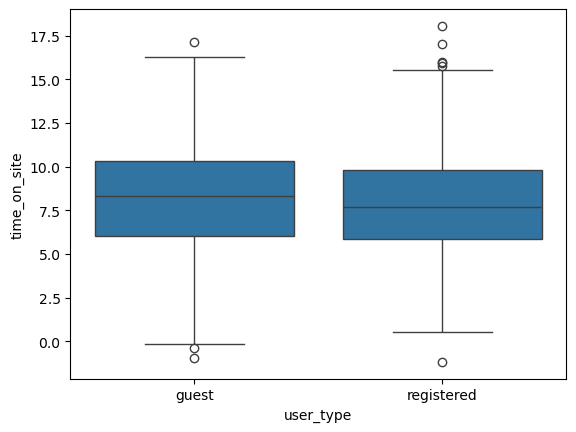

In [3]:
# 문제3
data.groupby('user_type')["time_on_site"].mean()
sns.boxplot(data=data, x="user_type", y="time_on_site")
plt.show()

답04 = 2

In [4]:
# 문제4
time_on_site_med = data['time_on_site'].median()
cart_value_mean = data['cart_value'].mean()

data['time_on_site'].fillna(time_on_site_med, inplace=True)
data['cart_value'].fillna(cart_value_mean, inplace=True)

/var/folders/m6/c6m74yfx4y5c_rlvr7fp5hrm0000gn/T/ipykernel_7054/4136037.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['time_on_site'].fillna(time_on_site_med, inplace=True)
/var/folders/m6/c6m74yfx4y5c_rlvr7fp5hrm0000gn/T/ipykernel_7054/4136037.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values a

In [5]:
# 문제5
data['prev_purchase'] = data['prev_purchase'].map({"Y" : 1, "N" : 0})
data['discount_applied'] = data['discount_applied'].map({"Y" : 1, "N" : 0})
data['user_type'] = data['user_type'].map({'registered':1, 'guest':0})

cat_col = ['device', 'country', 'payment_method']

incoding_df = pd.get_dummies(data, columns=cat_col, drop_first=True)

In [6]:
# 문제6
incoding_df.drop('num_items', axis=1, inplace=True)

In [7]:
# 문제7
filtering_df = incoding_df.drop(incoding_df[incoding_df['time_on_site'] < 0].index, axis=0)
filtering_df.reset_index(drop=True, inplace=True)

In [8]:
filtering_df['time_on_site']

0        8.095
1        8.540
2        7.160
3        4.130
4        7.590
         ...  
1291     8.760
1292    10.500
1293     6.820
1294     6.210
1295     5.720
Name: time_on_site, Length: 1296, dtype: float64

In [9]:
# 문제8
X = filtering_df.drop(columns='cart_abandon_yn', axis=1)
y = filtering_df['cart_abandon_yn']

In [10]:
# 문제9
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(X, y, random_state=42, test_size=0.2, stratify=y)

In [11]:
from sklearn.preprocessing import StandardScaler
# 문제10
ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_valid)

In [12]:
# 문제11
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(
    n_estimators=100,
    max_depth=7,
    random_state=42
)
rfc.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,7
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
from xgboost import XGBClassifier

In [14]:
# 문제12
# Initialize XGBoost classifier with optimized hyperparameters
xgbc = XGBClassifier(
    n_estimators=100,  # Number of gradient boosted trees
    max_depth=5,       # Maximum tree depth for base learners
    learning_rate=0.1, # Boosting learning rate
    random_state=42    # Random seed for reproducibility
)

# Train the model on the training data
xgbc.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [15]:
from sklearn.metrics import accuracy_score, f1_score

In [16]:
# 문제13
rfc_predict = rfc.predict(X_test)
xgbc_predict = xgbc.predict(X_test)

print('rfc acc: ', accuracy_score(y_valid, rfc_predict))
print('rfc f1: ', f1_score(y_valid, rfc_predict))
print('xgbc acc: ', accuracy_score(y_valid, xgbc_predict))
print('xgbc f1: ', f1_score(y_valid, xgbc_predict))

rfc acc:  0.6653846153846154
rfc f1:  0.02247191011235955
xgbc acc:  0.6384615384615384
xgbc f1:  0.17543859649122806


In [17]:
import tensorflow as tf

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
tf.random.set_seed(42)

y_train = to_categorical(y_train, num_classes=2)
y_valid = to_categorical(y_valid, num_classes=2)

In [ ]:
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(2, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(X_train, y_train, epochs=50, batch_size=128, validation_data=(X_valid, y_valid))

Epoch 1/50


/opt/anaconda3/envs/tf_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
